In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Installation


In [46]:
!pip install rouge-score pycocoevalcap

In [47]:
!pip install torchxrayvision

# Lib


In [117]:
import warnings
warnings.filterwarnings("ignore")

In [118]:
from typing import List

import os
import re
import ast
import math
import glob
import copy
import json
import random
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn.utils.rnn import pad_sequence
from torch.optim.lr_scheduler import CosineAnnealingLR

import torchxrayvision as xrv

from transformers import AutoTokenizer, AutoModel

import nltk

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("wordnet")
nltk.download("omw-1.4")

from nltk.tokenize import word_tokenize
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from pycocoevalcap.cider.cider import Cider
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [119]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Data Preparation


## Augumentation


In [120]:
IMG_SIZE = 224

train_transform = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomCrop(IMG_SIZE),
        transforms.ColorJitter(
            brightness=0.05,
            contrast=0.05,
        ),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.4888], std=[0.2839]),
    ]
)

val_transform = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.4888], std=[0.2839]),
    ]
)

## Vocabulary

`Vocabulary` có nhiệm vụ:
- Xây dựng từ điển từ tập văn bản huấn luyện.
- Ánh xạ từ -> số nguyên (`stoi`).
- Ánh xạ số nguyên -> từ (`itos`).
- Chuyển câu thành chuỗi ID để mô hình xử lý.
- Chuyển kết quả dự đoán từ ID về văn bản.

Special tokens:
- `PAD_TOKEN = "<PAD>"` # Bổ sung vào cuối câu để các câu có cùng độ dài
- `SOS_TOKEN = "<SOS>"` # Đánh dấu bắt đầu câu
- `EOS_TOKEN = "<EOS>"` # Đánh đâu kết thúc câu
- `UNK_TOKEN = "<UNK>"` # Đại diện cho từ không xuất hiện trong từ điển


In [121]:
class Vocabulary:
    PAD_TOKEN = "<PAD>"
    SOS_TOKEN = "<SOS>"
    EOS_TOKEN = "<EOS>"
    UNK_TOKEN = "<UNK>"

    PAD = 0
    SOS = 1
    EOS = 2
    UNK = 3

    def __init__(self, freq_threshold: int = 3):
        self.freq_threshold = freq_threshold

        self.itos = {
            self.PAD: self.PAD_TOKEN,
            self.SOS: self.SOS_TOKEN,
            self.EOS: self.EOS_TOKEN,
            self.UNK: self.UNK_TOKEN,
        }

        self.stoi = {v: k for k, v in self.itos.items()}

    def __len__(self) -> int:
        return len(self.itos)

    def build_vocabulary(self, corpus: List[str]) -> None:
        frequencies = Counter()
        idx = len(self.itos)

        for sentence in corpus:
            if not isinstance(sentence, str):
                continue

            for token in sentence.lower().split():
                frequencies[token] += 1

                if frequencies[token] >= self.freq_threshold and token not in self.stoi:
                    self.stoi[token] = idx
                    self.itos[idx] = token
                    idx += 1

    def numericalize(self, text: str) -> List[int]:
        if not isinstance(text, str):
            return []

        return [self.stoi.get(token, self.UNK) for token in text.lower().split()]

    def decode(
        self,
        ids: List[int],
        skip_special: bool = True,
    ) -> str:

        special_tokens = {
            self.PAD,
            self.SOS,
            self.EOS,
        }

        words = []

        for idx in ids:

            if skip_special and idx in special_tokens:
                continue

            words.append(self.itos.get(idx, self.UNK_TOKEN))

        return " ".join(words)

## Dataset custom

`MIMICCXRDataset` dùng để:
- Đọc ảnh X-ray từ thư mục lưu trữ.
- Đọc báo cáo (caption) tương ứng.
- Tiền xử lý ảnh.
- Chuyển văn bản thành chuỗi ID.
- Trả về dữ liệu để `DataLoader` tạo batch huấn luyện.

In [122]:
class MIMICCXRDataset(Dataset):
    def __init__(
        self,
        df,
        root_dir: str,
        vocab: Vocabulary,
        transform=None,
        max_length: int = 120,
    ):
        self.records = df.to_dict("records")

        self.root_dir = root_dir
        self.vocab = vocab
        self.transform = transform
        self.max_length = max_length

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, index: int):

        row = self.records[index]

        caption = row["text"]

        image_rel_path = row["best_image"]

        image_path = os.path.join(
            self.root_dir,
            image_rel_path,
        )

        if not os.path.exists(image_path):
            raise FileNotFoundError(image_path)

        img = Image.open(image_path).convert("L")

        if self.transform is not None:
            img = self.transform(img)

        tokens = self.vocab.numericalize(caption)

        tokens = tokens[: self.max_length - 2]

        caption_ids = [self.vocab.SOS] + tokens + [self.vocab.EOS]

        caption_tensor = torch.tensor(
            caption_ids,
            dtype=torch.long,
        )

        return (
            img,
            caption_tensor,
            image_path,
        )

## Collate

`MyCollate` được sử dụng để:
- Ghép nhiều ảnh thành một batch tensor.
- Padding các caption có độ dài khác nhau.
- Giữ lại đường dẫn ảnh để phục vụ debug hoặc visualization.


In [123]:
class MyCollate:
    def __init__(self, pad_idx: int):
        self.pad_idx = pad_idx

    def __call__(self, batch):

        images = torch.stack(
            [sample[0] for sample in batch],
            dim=0,
        )

        captions = pad_sequence(
            [sample[1] for sample in batch],
            batch_first=True,
            padding_value=self.pad_idx,
        )

        paths = [sample[2] for sample in batch]

        return (
            images,
            captions,
            paths,
        )

# Func


## Utils

In [124]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = text.replace("findings:", "")
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def print_directory_structure(startpath, max_level=3):
    start_level = startpath.count(os.sep)
    for root, dirs, files in os.walk(startpath):
        level = root.count(os.sep) - start_level
        if level > max_level:
            del dirs[:]
            continue
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        if level < max_level:
            subindent = ' ' * 4 * (level + 1)
            for f in files:
                print(f'{subindent}{f}')

In [125]:
def _masked_mean(
    x: torch.Tensor,
    mask: torch.Tensor,
):
    mask = mask.unsqueeze(-1).float()

    return (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)

def _info_nce_loss(
    image_features,
    text_features,
    temperature,
):
    if image_features.size(0) < 2:
        return image_features.new_tensor(0.0)

    image_features = F.normalize(
        image_features,
        dim=-1,
    )

    text_features = F.normalize(
        text_features,
        dim=-1,
    )

    logits = image_features @ text_features.T
    logits = logits / temperature

    labels = torch.arange(
        image_features.size(0),
        device=image_features.device,
    )

    loss_i2t = F.cross_entropy(
        logits,
        labels,
    )

    loss_t2i = F.cross_entropy(
        logits.T,
        labels,
    )

    return 0.5 * (loss_i2t + loss_t2i)

## Train

In [126]:
def train_model(
    model,
    train_loader,
    val_loader,
    device,
    vocab,
    epochs=10,
    lr=1e-3,
    criterion=None,
    optimizer=None,
    scheduler=None,
    checkpoint=None,
    save_path="checkpoint.pth",
    nce_weight: float = 0.1,
    nce_temperature: float = 0.07,
):
    def _unwrap_model(current_model):
        return (
            current_model.module if hasattr(current_model, "module") else current_model
        )

    start_epoch = 0
    best_epoch = -1
    best_val_loss = float("inf")

    history = {
        "train_loss": [],
        "val_loss": [],
        "lr": [],
    }

    chk = None
    has_checkpoint = checkpoint is not None and os.path.exists(checkpoint)

    # LOAD CHECKPOINT
    if has_checkpoint:
        print(f"[Train] Loading checkpoint: {checkpoint}")
        chk = torch.load(checkpoint, map_location=device)

        model.load_state_dict(chk["model"])
        start_epoch = chk.get("last_epoch", 0) + 1
        best_epoch = chk.get("best_epoch", -1)
        best_val_loss = chk.get("best_val_loss", float("inf"))
        history = chk.get("history", history)

    model = model.to(device)
    core_model = _unwrap_model(model)

    # PRIORITY RULE: USER > CHECKPOINT > DEFAULT

    # OPTIMIZER
    if optimizer is None:
        optimizer = optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=lr,
            weight_decay=1e-4,
        )
        use_ckpt_optimizer = has_checkpoint
    else:
        use_ckpt_optimizer = False

    if use_ckpt_optimizer and chk is not None and "optimizer" in chk:
        try:
            optimizer.load_state_dict(chk["optimizer"])
        except Exception as e:
            print(f"[Warning] Cannot load optimizer state: {e}")

    # SCHEDULER
    if scheduler is None:
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=10,
            eta_min=1e-5,
        )
        use_ckpt_scheduler = has_checkpoint
    else:
        use_ckpt_scheduler = False

    if (
        use_ckpt_scheduler
        and chk is not None
        and "scheduler" in chk
        and chk["scheduler"] is not None
    ):
        try:
            scheduler.load_state_dict(chk["scheduler"])
        except Exception as e:
            print(f"[Warning] Cannot load scheduler state: {e}")

    # LOSS (criterion)
    if criterion is None:
        criterion = nn.CrossEntropyLoss(
            ignore_index=vocab.PAD,
            label_smoothing=0.1,
        )

    # BEST MODEL
    if has_checkpoint and chk is not None and "best_model" in chk:
        best_model_wts = copy.deepcopy(chk["best_model"])
    else:
        best_model_wts = copy.deepcopy(model.state_dict())

    total_epochs = start_epoch + epochs
    last_epoch = start_epoch - 1

    print(f"[Train] Start epoch: {start_epoch}")

    # TRAIN LOOP
    for epoch in range(start_epoch, total_epochs):
        last_epoch = epoch

        # TRAIN STEP
        model.train()
        train_loss = 0.0

        for imgs, captions, _ in train_loader:
            imgs = imgs.to(device)
            captions = captions.to(device)
            optimizer.zero_grad()
            logits, memory, hidden = core_model.forward_with_features(
                imgs,
                captions,
                pad_idx=vocab.PAD,
            )
            targets = captions[:, 1:]
            ce_loss = criterion(
                logits.reshape(
                    -1,
                    logits.size(-1),
                ),
                targets.reshape(-1),
            )
            image_features = core_model.image_proj(memory.mean(dim=1))
            caption_mask = captions[:, :-1] != vocab.PAD
            text_features = core_model.text_proj(
                _masked_mean(
                    hidden,
                    caption_mask,
                )
            )
            nce_loss = _info_nce_loss(
                image_features,
                text_features,
                nce_temperature,
            )
            loss = ce_loss + nce_weight * nce_loss
            loss.backward()
            nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0,
            )
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # VALIDATION STEP
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for imgs, captions, _ in val_loader:
                imgs = imgs.to(device)
                captions = captions.to(device)
                logits, memory, hidden = core_model.forward_with_features(
                    imgs,
                    captions,
                    pad_idx=vocab.PAD,
                )
                targets = captions[:, 1:]
                ce_loss = criterion(
                    logits.reshape(
                        -1,
                        logits.size(-1),
                    ),
                    targets.reshape(-1),
                )
                caption_mask = captions[:, :-1] != vocab.PAD
                image_features = core_model.image_proj(memory.mean(dim=1))
                text_features = core_model.text_proj(
                    _masked_mean(
                        hidden,
                        caption_mask,
                    )
                )
                nce_loss = _info_nce_loss(
                    image_features,
                    text_features,
                    nce_temperature,
                )
                loss = ce_loss + nce_weight * nce_loss
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)

        # UPDATE LEARNING RATE
        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["lr"].append(current_lr)

        # SCHEDULER STEP
        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(avg_val_loss)
            else:
                scheduler.step()

        # LOG
        print(
            f"[{model.__class__.__name__}] "
            f"Epoch {epoch+1:02d}/{total_epochs:02d} | "
            f"lr={current_lr:.6f} | "
            f"train_loss={avg_train_loss:.4f} | "
            f"val_loss={avg_val_loss:.4f}"
        )

        # BEST PARAMS
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = epoch
            best_model_wts = copy.deepcopy(model.state_dict())

    # SAVE CHECKPOINT
    final_model_wts = copy.deepcopy(model.state_dict())

    torch.save(
        {
            "last_epoch": last_epoch,
            "model": final_model_wts,
            "optimizer": optimizer.state_dict() if optimizer else None,
            "scheduler": scheduler.state_dict() if scheduler else None,
            "best_model": best_model_wts,
            "best_epoch": best_epoch,
            "best_val_loss": best_val_loss,
            "history": history,
        },
        save_path,
    )

    print(f"[Train] Checkpoint saved: {save_path}")

    # Load best model
    model.load_state_dict(best_model_wts)

    return model, history

## Plot

In [127]:
def plot_loss(history, title="Loss"):
    plt.figure(figsize=(16, 5))
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

## Evaluation

In [128]:
def evaluate_model(
    model,
    data_loader,
    vocab,
    device,
    use_beam: bool = True,
    beam_size: int = 5,
    split_name: str = "test",
) -> pd.DataFrame:

    model.eval()

    references_bleu = []
    hypotheses_bleu = []

    references_str = {}
    hypotheses_str = {}

    image_id = 0

    with torch.inference_mode():
        for imgs, captions, _ in tqdm(
            data_loader,
            desc=f"  Eval [{split_name}]",
            leave=False,
        ):
            imgs = imgs.to(device, non_blocking=True)

            captions_list = captions.cpu().tolist()

            with torch.autocast(device_type=device.type, dtype=torch.float16):
                for i in range(imgs.size(0)):

                    img = imgs[i].unsqueeze(0)

                    if use_beam and hasattr(model, "beam_search"):
                        hyp_words = model.beam_search(
                            img,
                            vocab,
                            beam_size=beam_size,
                        )
                    else:
                        hyp_words = model.generate_caption(img, vocab)

                    ref_words = []

                    for idx in captions_list[i]:
                        word = vocab.itos.get(idx, "<UNK>")

                        if word in ("<EOS>", "<eos>"):
                            break

                        if word not in (
                            "<SOS>",
                            "<sos>",
                            "<PAD>",
                            "<pad>",
                        ):
                            ref_words.append(word)

                    hypotheses_bleu.append(hyp_words)
                    references_bleu.append([ref_words])

                    hyp_str = " ".join(hyp_words)
                    ref_str = " ".join(ref_words)

                    hypotheses_str[image_id] = [hyp_str]
                    references_str[image_id] = [ref_str]

                    image_id += 1

    r_scorer = rouge_scorer.RougeScorer(
        ["rougeL"],
        use_stemmer=True,
    )

    rouge_scores = [
        r_scorer.score(
            references_str[k][0],
            hypotheses_str[k][0],
        )["rougeL"].fmeasure
        for k in range(image_id)
    ]

    rouge_l = float(np.mean(rouge_scores)) if rouge_scores else 0.0

    smooth = SmoothingFunction().method4

    bleu1 = corpus_bleu(
        references_bleu,
        hypotheses_bleu,
        weights=(1, 0, 0, 0),
        smoothing_function=smooth,
    )

    bleu2 = corpus_bleu(
        references_bleu,
        hypotheses_bleu,
        weights=(0.5, 0.5, 0, 0),
        smoothing_function=smooth,
    )

    bleu3 = corpus_bleu(
        references_bleu,
        hypotheses_bleu,
        weights=(0.33, 0.33, 0.33, 0),
        smoothing_function=smooth,
    )

    bleu4 = corpus_bleu(
        references_bleu,
        hypotheses_bleu,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smooth,
    )

    meteor_scores = []

    for k in range(image_id):
        ref_tokens = references_str[k][0].split()
        hyp_tokens = hypotheses_str[k][0].split()

        score = meteor_score(
            [ref_tokens],
            hyp_tokens,
        )

        meteor_scores.append(score)

    meteor_avg = (
        float(np.mean(meteor_scores))
        if meteor_scores
        else 0.0
    )

    try:
        cider_score, _ = Cider().compute_score(
            references_str,
            hypotheses_str,
        )
        cider_score = round(float(cider_score), 4)

    except Exception:
        cider_score = "N/A"

    df = pd.DataFrame(
        [{
            "Model": model.__class__.__name__,
            "Split": split_name,
            "BLEU-1": round(bleu1, 4),
            "BLEU-2": round(bleu2, 4),
            "BLEU-3": round(bleu3, 4),
            "BLEU-4": round(bleu4, 4),
            "ROUGE-L": round(rouge_l, 4),
            "METEOR": round(meteor_avg, 4),
            "CIDEr": cider_score,
        }]
    )

    return df

## Inference

In [129]:
def inference(
    model1,
    model2,
    dataset,
    vocab,
    n_sample=12,
    cols=4,
    device="cuda",
):

    if model1 is not None:
        model1.to(device)
        model1.eval()

    if model2 is not None:
        model2.to(device)
        model2.eval()

    rows = int(np.ceil(n_sample / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 6))

    axes = np.array(axes).reshape(-1)

    random_indices = random.sample(range(len(dataset)), min(n_sample, len(dataset)))

    for i, idx in enumerate(random_indices):

        img_tensor, caption_tensor, img_path = dataset[idx]

        img_input = img_tensor.unsqueeze(0).to(device)

        # Ground Truth
        gt_words = []

        for token in caption_tensor:
            word = vocab.itos[token.item()]

            if word == "<EOS>":
                break

            if word not in ["<SOS>", "<PAD>"]:
                gt_words.append(word)

        gt_text = " ".join(gt_words)

        title_lines = [f"GT: {gt_text[:120]}"]

        # Model 1
        if model1 is not None:
            pred1 = " ".join(model1.generate_caption(img_input, vocab))
            title_lines.append(f"M1: {pred1}")

        # Model 2
        if model2 is not None:
            pred2 = " ".join(model2.generate_caption(img_input, vocab))
            title_lines.append(f"M2: {pred2}")

        title = "\n".join(title_lines)

        img_plot = img_tensor.clone()

        img_plot = img_plot * 0.5 + 0.5

        img_plot = img_plot.squeeze(0).cpu().numpy()

        img_plot = np.clip(img_plot, 0, 1)

        ax = axes[i]

        ax.imshow(img_plot, cmap="gray")

        ax.axis("off")

        ax.set_title(title, fontsize=8, loc="left", wrap=True)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

## Load

In [130]:
def load_model(
    model,
    checkpoint_path,
    device,
    method="inference",
    optimizer=None,
    scheduler=None,
):
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint file not found at: {checkpoint_path}")

    print(f"[Load] Loading checkpoint from: '{checkpoint_path}'...")

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
    )

    # Load weights
    if method == "inference" and "best_model" in checkpoint:
        model.load_state_dict(checkpoint["best_model"])
        print("[Load] Loaded BEST model.")
    else:
        model.load_state_dict(checkpoint["model"])
        print("[Load] Loaded model.")

    model.to(device)

    history = checkpoint.get(
        "history",
        {
            "train_loss": [],
            "val_loss": [],
            "lr": [],
        },
    )

    # Inference
    if method == "inference":
        model.eval()
        return model, history

    # Resume Training
    elif method == "train":
        if optimizer is None:
            raise ValueError("When method='train', " "optimizer must be provided.")
        if "optimizer" in checkpoint and checkpoint["optimizer"] is not None:
            optimizer.load_state_dict(checkpoint["optimizer"])
            print("[Load - Train] " "Loaded optimizer state.")
        if (
            scheduler is not None
            and "scheduler" in checkpoint
            and checkpoint["scheduler"] is not None
        ):
            scheduler.load_state_dict(checkpoint["scheduler"])
            print("[Load - Train] " "Loaded scheduler state.")

        start_epoch = checkpoint.get("last_epoch", -1) + 1

        best_val_loss = checkpoint.get(
            "best_val_loss",
            float("inf"),
        )
        best_epoch = checkpoint.get(
            "best_epoch",
            -1,
        )

        print(f"[Load - Train] Resume from " f"epoch {start_epoch}")

        return (
            model,
            optimizer,
            scheduler,
            start_epoch,
            best_epoch,
            best_val_loss,
            history,
        )

    else:
        raise ValueError("method must be " "'inference' or 'train'")

# Architecture


## DenseNet121 + Transformer (Constractive learning)



In [131]:
class CNNEncoder(nn.Module):
    def __init__(self, embed_size: int, fine_tune: bool = True):
        super().__init__()

        # DenseNet121 pre-trained on x-ray
        densenet = xrv.models.DenseNet(weights="densenet121-res224-all")

        self.features = densenet.features

        for p in self.features.parameters():
            p.requires_grad = False

        if fine_tune:
            for name, p in self.features.named_parameters():
                if "denseblock3" in name or "denseblock4" in name or "norm5" in name:
                    p.requires_grad = True

        self.pool = nn.AdaptiveAvgPool2d((7, 7))
        self.proj = nn.Linear(1024, embed_size)
        self.norm = nn.LayerNorm(embed_size)
        self.pos_embed = nn.Parameter(torch.randn(1, 49, embed_size) * 0.02)
        self.dropout = nn.Dropout(0.1)

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        feat = self.features(images)
        feat = self.pool(feat)

        B, C, H, W = feat.shape
        feat = feat.view(B, C, H * W).permute(0, 2, 1)

        feat = self.norm(F.relu(self.proj(feat)))
        feat = feat + self.pos_embed
        return self.dropout(feat)

In [132]:
class PositionalEncoding(nn.Module):
    def __init__(
        self,
        embed_size: int,
        max_len: int = 512,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, embed_size)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, embed_size, 2, dtype=torch.float)
            * (-math.log(10000.0) / embed_size)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer(
            "pe",
            pe.unsqueeze(0),
            persistent=False,
        )

    def forward(self, x):
        x = x + self.pe[:, : x.size(1)]
        return self.dropout(x)


class TransformerDecoder(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embed_size: int = 512,
        num_heads: int = 8,
        num_layers: int = 6,
        ff_dim: int = 2048,
        dropout: float = 0.1,
        max_len: int = 512,
    ):
        super().__init__()

        self.embed_size = embed_size

        self.embed = nn.Embedding(
            vocab_size,
            embed_size,
            padding_idx=0,
        )

        self.pos_enc = PositionalEncoding(
            embed_size=embed_size,
            max_len=max_len,
            dropout=dropout,
        )

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=embed_size,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.transformer_decoder = nn.TransformerDecoder(
            decoder_layer,
            num_layers=num_layers,
            norm=nn.LayerNorm(embed_size),
        )

        self.pre_head_norm = nn.LayerNorm(embed_size)

        self.fc_out = nn.Linear(
            embed_size,
            vocab_size,
            bias=False,
        )

        self._init_weights()
        self.fc_out.weight = self.embed.weight
        self.register_buffer(
            "_causal_mask",
            torch.empty(0),
            persistent=False,
        )

    def _init_weights(self):

        nn.init.normal_(
            self.embed.weight,
            mean=0.0,
            std=0.02,
        )

        if self.embed.padding_idx is not None:
            with torch.no_grad():
                self.embed.weight[self.embed.padding_idx].fill_(0)

    def _get_causal_mask(
        self,
        size: int,
        device,
    ):

        if self._causal_mask.numel() == 0 or self._causal_mask.size(0) < size:

            mask = torch.triu(
                torch.ones(size, size),
                diagonal=1,
            ).bool()

            self._causal_mask = mask

        return self._causal_mask[:size, :size].to(device)

    def forward(
        self,
        tgt,
        memory,
        tgt_key_padding_mask=None,
        memory_key_padding_mask=None,
        return_hidden=False,
    ):

        T = tgt.size(1)

        tgt_emb = self.embed(tgt)
        tgt_emb = tgt_emb * math.sqrt(self.embed_size)
        tgt_emb = self.pos_enc(tgt_emb)

        causal_mask = self._get_causal_mask(
            T,
            tgt.device,
        )

        hidden = self.transformer_decoder(
            tgt=tgt_emb,
            memory=memory,
            tgt_mask=causal_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=memory_key_padding_mask,
        )

        hidden = self.pre_head_norm(hidden)

        if return_hidden:
            return hidden

        logits = self.fc_out(hidden)

        return logits

In [133]:
class ImageCaptioningModel(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embed_size: int = 512,
        num_heads: int = 8,
        num_layers: int = 4,
        ff_dim: int = 2048,
        dropout: float = 0.1,
        max_len: int = 512,
        fine_tune_cnn: bool = True,
    ):
        super().__init__()
        self.encoder = CNNEncoder(embed_size, fine_tune=fine_tune_cnn)
        self.decoder = TransformerDecoder(
            vocab_size=vocab_size,
            embed_size=embed_size,
            num_heads=num_heads,
            num_layers=num_layers,
            ff_dim=ff_dim,
            dropout=dropout,
            max_len=max_len,
        )
        self.image_proj = nn.Sequential(
            nn.Linear(embed_size, embed_size),
            nn.GELU(),
            nn.LayerNorm(embed_size),
            nn.Linear(embed_size, 256),
        )
        self.text_proj = nn.Sequential(
            nn.Linear(embed_size, embed_size),
            nn.GELU(),
            nn.LayerNorm(embed_size),
            nn.Linear(embed_size, 256),
        )

    def forward(
        self,
        images: torch.Tensor,
        captions: torch.Tensor,
        pad_idx: int = 0,
    ) -> torch.Tensor:
        memory = self.encoder(images)
        tgt_in = captions[:, :-1]

        pad_mask = tgt_in == pad_idx

        logits = self.decoder(
            tgt=tgt_in,
            memory=memory,
            tgt_key_padding_mask=pad_mask,
            memory_key_padding_mask=None,
        )
        return logits

    def forward_with_features(
        self,
        images: torch.Tensor,
        captions: torch.Tensor,
        pad_idx: int = 0,
    ):

        memory = self.encoder(images)
        tgt_in = captions[:, :-1]
        pad_mask = tgt_in == pad_idx
        hidden = self.decoder(
            tgt=tgt_in,
            memory=memory,
            tgt_key_padding_mask=pad_mask,
            return_hidden=True,
        )
        logits = self.decoder.fc_out(hidden)

        return logits, memory, hidden

    @torch.no_grad()
    def generate_caption(
        self,
        image: torch.Tensor,
        vocab,
        max_len: int = 100,
    ) -> list[str]:
        self.eval()
        memory = self.encoder(image)
        tokens = [vocab.SOS]

        for _ in range(max_len):
            tgt = torch.tensor([tokens], device=image.device)
            logits = self.decoder(tgt, memory)
            nxt = logits[0, -1].argmax().item()
            if nxt == vocab.EOS:
                break
            tokens.append(nxt)

        return vocab.decode(tokens[1:]).split()

    @torch.no_grad()
    def beam_search(
        self,
        image: torch.Tensor,
        vocab,
        beam_size: int = 5,
        max_len: int = 100,
    ) -> list[str]:
        self.eval()
        memory = self.encoder(image)
        beams = [(0.0, [vocab.SOS])]
        done = []

        for _ in range(max_len):
            candidates = []
            for score, tokens in beams:
                tgt = torch.tensor([tokens], device=image.device)
                logits = self.decoder(tgt, memory)
                log_prob = F.log_softmax(logits[0, -1], dim=-1)
                topk_lp, topk_id = log_prob.topk(beam_size)

                for lp, tid in zip(topk_lp.tolist(), topk_id.tolist()):
                    candidates.append((score + lp, tokens + [tid]))

            candidates.sort(key=lambda x: x[0], reverse=True)
            beams = []
            for s, toks in candidates[:beam_size]:
                if toks[-1] == vocab.EOS:
                    done.append((s / len(toks), toks))
                else:
                    beams.append((s, toks))
            if not beams:
                break

        if done:
            done.sort(key=lambda x: x[0], reverse=True)
            best_tokens = done[0][1]
        else:
            best_tokens = max(beams, key=lambda x: x[0])[1]

        return vocab.decode(best_tokens[1:]).split()

# Main


## Load data

### Dowload

In [134]:
DATA_DIR = kagglehub.dataset_download("simhadrisadaram/mimic-cxr-dataset")
print("Path to dataset files:", DATA_DIR)

Using Colab cache for faster access to the 'mimic-cxr-dataset' dataset.
Path to dataset files: /kaggle/input/mimic-cxr-dataset


In [135]:
split_dir = kagglehub.dataset_download("avcuongy/mimic-cxr-split")
print("Path to dataset files:", split_dir)

Path to dataset files: /root/.cache/kagglehub/datasets/avcuongy/mimic-cxr-split/versions/1


In [136]:
ROOT_DIR = os.path.join(DATA_DIR, "official_data_iccv_final")
TRAIN_CSV = os.path.join(split_dir, "mimic_train.csv")
VAL_CSV = os.path.join(split_dir, "mimic_val.csv")
TEST_CSV = os.path.join(split_dir, "mimic_test.csv")

print(f"DATA_DIR: {DATA_DIR}")
print(f"TRAIN CSV: {TRAIN_CSV}")
print(f"VAL CSV: {VAL_CSV}")
print(f"TEST CSV: {TEST_CSV}")

DATA_DIR: /kaggle/input/mimic-cxr-dataset
TRAIN CSV: /root/.cache/kagglehub/datasets/avcuongy/mimic-cxr-split/versions/1/mimic_train.csv
VAL CSV: /root/.cache/kagglehub/datasets/avcuongy/mimic-cxr-split/versions/1/mimic_val.csv
TEST CSV: /root/.cache/kagglehub/datasets/avcuongy/mimic-cxr-split/versions/1/mimic_test.csv


### Loader

In [137]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print(f"{train_df.shape}")
print(f"{val_df.shape}")
print(f"{test_df.shape}")

(50009, 5)
(10000, 5)
(10003, 5)


In [138]:
val_grouped = val_df.drop_duplicates(subset=['subject_id', 'text']).groupby('subject_id').first()
val_df_sampled = val_grouped.sample(n=min(1000, len(val_grouped)), random_state=42).reset_index()

test_grouped = test_df.drop_duplicates(subset=['subject_id', 'text']).groupby('subject_id').first()
test_df_sampled = test_grouped.sample(n=min(1000, len(test_grouped)), random_state=42).reset_index()

val_df = val_df_sampled
test_df = test_df_sampled

print(f"Train : {len(train_df):,} images | {train_df['subject_id'].nunique():,} patients")
print(f"Val   : {len(val_df):,} images | {val_df['subject_id'].nunique():,} patients")
print(f"Test  : {len(test_df):,} images | {test_df['subject_id'].nunique():,} patients")

Train : 50,009 images | 8,863 patients
Val   : 1,000 images | 1,000 patients
Test  : 1,000 images | 1,000 patients


In [139]:
for df in [train_df, val_df, test_df]:
    df["text"] = df["text"].fillna("").apply(clean_text)

In [140]:
train_df.iloc[1, :]

,1
subject_id,15761456
view,['AP']
best_image,files/p15/p15761456/s54662596/0081fa27-d27d9e0...
path,files/p15/p15761456/s54662596/0081fa27-d27d9e0...
text,compared to the lung volumes are lower likely ...


In [141]:
freq_threshold = 10
vocab = Vocabulary(freq_threshold=freq_threshold)
vocab.build_vocabulary(train_df["text"].tolist())
print(f"Vocabulary size: {len(vocab)}")

my_collate = MyCollate(pad_idx=vocab.PAD)

Vocabulary size: 2853


In [142]:
batch_size = 32
num_workers = 4

train_dataset = MIMICCXRDataset(df=train_df, root_dir=ROOT_DIR, transform=train_transform, vocab=vocab)
val_dataset = MIMICCXRDataset(df=val_df, root_dir=ROOT_DIR, transform=val_transform, vocab=vocab)
test_dataset = MIMICCXRDataset(df=test_df, root_dir=ROOT_DIR, transform=val_transform, vocab=vocab)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=True,
    collate_fn=my_collate
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False,
    collate_fn=my_collate
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False,
    collate_fn=my_collate
)

print(f"Total images in train : {len(train_dataset)}")
print(f"Total images in val   : {len(val_dataset)}")
print(f"Total images in test  : {len(test_dataset)}")

Total images in train : 50009
Total images in val   : 1000
Total images in test  : 1000


In [143]:
print(f"Total batch in train_loader: {len(train_loader)}")
print(f"Total batch in val_loader: {len(val_loader)}")
print(f"Total batch in test_loader: {len(test_loader)}")

Total batch in train_loader: 1563
Total batch in val_loader: 32
Total batch in test_loader: 32


In [144]:
imgs, captions, _ = next(iter(train_loader))

print(imgs.shape)
print(imgs.min(), imgs.max())

torch.Size([32, 1, 224, 224])
tensor(-1.7217) tensor(1.8006)


Image batch shape   : torch.Size([32, 1, 224, 224])
Caption batch shape : torch.Size([32, 120])


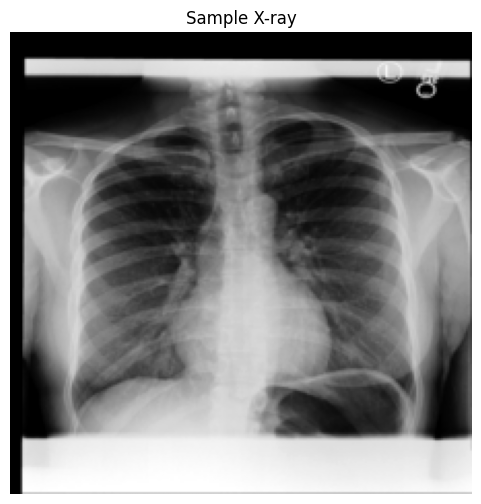


Caption:
<SOS> the cardiac mediastinal and hilar contours appear stable there is no pleural effusion or pneumothorax the lungs appear clear bony structures are unremarkable there has been no significant change impression no evidence of acute cardiopulmonary disease


In [145]:
batch = next(iter(train_loader))
imgs = batch[0]
captions = batch[1]
print(f"Image batch shape   : {imgs.shape}")
print(f"Caption batch shape : {captions.shape}")
img_tensor = imgs[0]
inv_normalize = transforms.Normalize(mean=[-1.0], std=[2.0])
img_plot = inv_normalize(img_tensor)
img_plot = img_plot.squeeze(0).numpy()
plt.figure(figsize=(6, 6))
plt.imshow(img_plot, cmap="gray")
plt.title("Sample X-ray")
plt.axis("off")
plt.show()
caption_tensor = captions[0]
words = []
for token in caption_tensor:
    word = vocab.itos[token.item()]

    if word == "<EOS>":
        break

    if word != "<PAD>":
        words.append(word)
decoded_caption = " ".join(words)
print("\nCaption:")
print(decoded_caption)

## Config

In [149]:
VOCAB_SIZE = len(vocab)

EMBED_SIZE = 256
NUM_HEADS = 8
NUM_LAYERS = 4
FF_DIM = 1024
DROPOUT = 0.3
MAX_LEN = 120

In [150]:
model = ImageCaptioningModel(
    vocab_size=VOCAB_SIZE,
    embed_size=EMBED_SIZE,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    ff_dim=FF_DIM,
    dropout=DROPOUT,
    max_len=MAX_LEN,
    fine_tune_cnn=True
).to(device)

In [151]:
LEARNING_RATE = 1e-4
EPOCHS = 10
NCE_WEIGHT = 0.2
NCE_TEMPERATURE = 0.07

criterion = nn.CrossEntropyLoss(ignore_index=vocab.PAD,label_smoothing=0.1)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=1e-4,
    betas=(0.9, 0.98),
)

scheduler = CosineAnnealingLR(
    optimizer,
    T_max   = EPOCHS,
    eta_min = 1e-6,
)

## Train

In [ ]:
model, history = train_model(
    model,
    train_loader,
    val_loader,
    device,
    vocab,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    checkpoint=None,
    save_path="/content/drive/MyDrive/UEH TERMS/Kì 6/Tutorial Deep Learning/colab/models/model.pth",
    nce_weight=NCE_WEIGHT,
    nce_temperature=NCE_TEMPERATURE,
)

[Train] Start epoch: 0


## Train continue

In [ ]:
model, history = train_model(
    model,
    train_loader,
    val_loader,
    device,
    vocab,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    criterion=criterion,
    optimizer=None,
    scheduler=None,
    checkpoint="/content/drive/MyDrive/UEH TERMS/Kì 6/Tutorial Deep Learning/colab/models/model.pth",
    save_path="/content/drive/MyDrive/UEH TERMS/Kì 6/Tutorial Deep Learning/colab/models/model1.pth",
)

# I/O


In [80]:
MODEL_PATH = "/content/drive/MyDrive/UEH TERMS/Kì 6/Tutorial Deep Learning/colab/models/model.pth"

## Load

In [81]:
model, history = load_model(
    model=model,
    checkpoint_path=MODEL_PATH,
    device=device,
    method="inference"
)

[Load] Loading checkpoint from: '/content/drive/MyDrive/UEH TERMS/Kì 6/Tutorial Deep Learning/colab/models/model.pth'...
[Load] Loaded BEST model.


## Plot loss

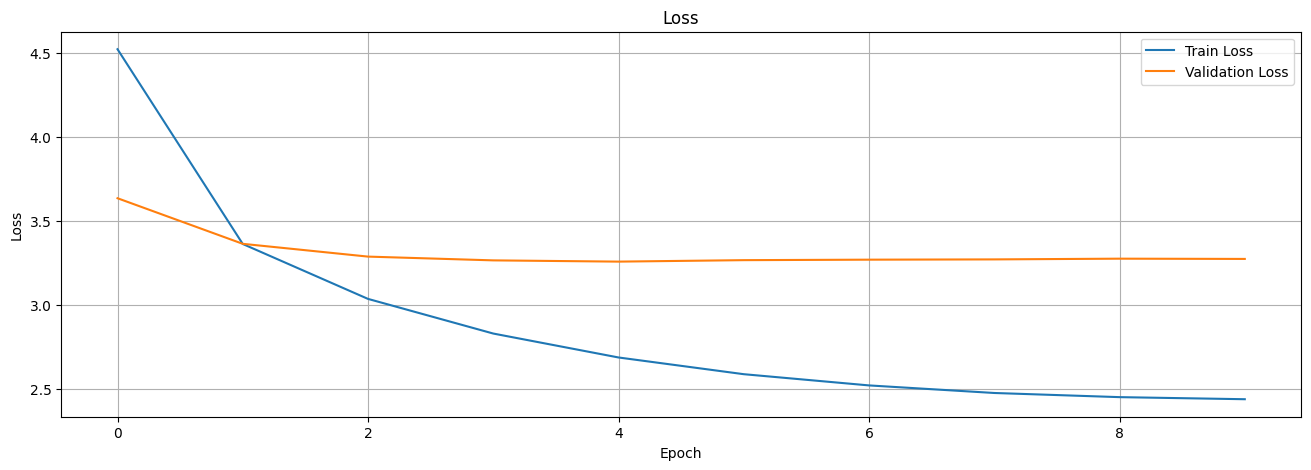

In [82]:
plot_loss(history)

## Eval

In [ ]:
evaluate_model(model, test_loader, vocab, device)

## Inference

In [ ]:
inference(
    model1 = model,
    model2 = None,
    dataset = test_dataset,
    vocab = vocab,
    n_sample = 2,
    cols = 1,
    device = device
)